# Classical Monte Carlo benchmark for quantum CVA

In [12]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

from matplotlib.ticker import LogLocator, LogFormatterMathtext
from benchmark_utils import (P0, build_survival_from_cds,
                             simulate_S, discrete_cva, discrete_cva_paper_form)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### CVA of a  *single underlying Equity-Forward*

Specifications of the estimation using classical Monte Carlo methods: 

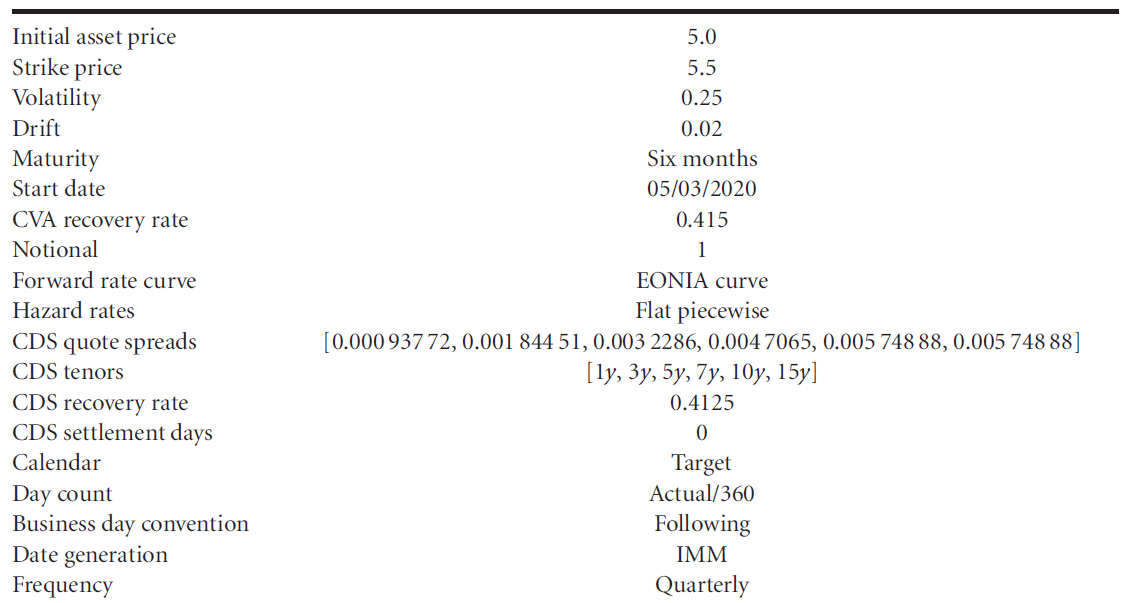

In [2]:
# =============================
# Simulation parameters
# =============================
S0 = 5.0
K = 5.5
sigma = 0.25
mu = 0.02
r = -0.54/100 # approx flat curve from market data

R_cva = 0.415
R_cds = 0.4125
LGD = 1.0 - R_cva

T = 184/360
N_paths = 100_000
M = 4
t = np.linspace(0.0, T, M+1)

rng = np.random.default_rng()

# Flat-curve discount function for CDS bootstrap
P0_flat = lambda u: P0(u, r)

# CDS specifications
cds_tenors_years = [1, 3, 5, 7, 10, 15]
cds_spreads = [
    0.00093772,
    0.00184451,
    0.0032286,
    0.0047065,
    0.00574888,
    0.00574888
]

Default probabilities are obtained by calibrating a piecewise-constant hazard rate function to market CDS par spreads. The bootstrapping procedure does not compute survival probabilities directly; instead, it determines the hazard rates from which survival and default probabilities are subsequently derived.

In the paper, the hazard rate is assumed to be constant between consecutive CDS maturities:
$$
\lambda(t) = \lambda_i \quad \text{for } t \in (T_{i-1}, T_i],
$$
where $\{T_i\}$ denote the CDS maturities. Given this (piecewise) specification, the survival probability admits the representation
$$
S(t) = \exp\!\left(-\int_0^t \lambda(s)\,ds\right)
= \exp\!\left(-\sum_{j=1}^{i-1} \lambda_j (T_j-T_{j-1}) - \lambda_i (t-T_{i-1})\right),
\qquad t \in (T_{i-1},T_i].
$$

For a CDS with maturity $T_i$ and market par spread $s_i$, the no-arbitrage condition requires the contract to have zero value at inception. This implies that the present value of the premium leg equals the present value of the protection leg:
$$
\mathrm{PV}_{\mathrm{premium}}(T_i;\lambda_1,\dots,\lambda_i)
=
\mathrm{PV}_{\mathrm{protection}}(T_i;\lambda_1,\dots,\lambda_i).
$$

Assuming quarterly payments with accrual fraction $\Delta t = 0.25$, the present value of the premium leg (without accrual on default) can be written as
$$
\mathrm{PV}_{\mathrm{premium}}(T_i)
=
\sum_{k=1}^{N_i}
s_i \, \Delta t \, P(0,t_k)\, S(t_k),
$$
where $t_k = k\Delta t$ and $N_i = T_i/\Delta t$. Each survival probability $S(t_k)$ depends explicitly on the hazard rates $\lambda_1,\dots,\lambda_i$, and in particular on $\lambda_i$ for payment dates beyond $T_{i-1}$.

The present value of the protection leg is given by
$$
\mathrm{PV}_{\mathrm{protection}}(T_i)
=
(1-R_{\mathrm{CDS}})
\sum_{k=1}^{N_i}
P(0,t_k)
\big(S(t_{k-1}) - S(t_k)\big),
$$
where $R_{\mathrm{CDS}}$ denotes the recovery rate. The term $S(t_{k-1}) - S(t_k)$ represents the probability of default in the interval $(t_{k-1},t_k]$ and is therefore a direct function of the hazard rates.

For a given maturity $T_i$, the hazard rates $\lambda_1,\dots,\lambda_{i-1}$ are already fixed from previous steps of the bootstrap. The equality between the premium and protection legs thus defines a single nonlinear equation in the unknown $\lambda_i$:
$$
\sum_{k=1}^{N_i}
s_i \, \Delta t \, P(0,t_k)\, S(t_k;\lambda_1,\dots,\lambda_i)
=
(1-R_{\mathrm{CDS}})
\sum_{k=1}^{N_i}
P(0,t_k)
\big(S(t_{k-1};\lambda_1,\dots,\lambda_i) - S(t_k;\lambda_1,\dots,\lambda_i)\big).
$$

This equation is solved numerically, typically using a root-finding algorithm such as bisection or Newton’s method. For each trial value of $\lambda_i$, the survival probabilities are computed from the exponential form above, the two legs are evaluated on the payment grid, and the pricing error is updated until convergence. Once $\lambda_i$ is determined, it is held fixed and the procedure proceeds to the next CDS maturity.

The output of the bootstrap is the set of calibrated hazard rates $\{\lambda_i\}$. From these, the survival curve and the associated default probabilities are obtained as
$$
S(t) = \exp\!\left(-\int_0^t \lambda(s)\,ds\right),
\qquad
q(t_{k-1},t_k) = S(t_{k-1}) - S(t_k),
$$
which are the quantities subsequently used in the CVA computation.

In [3]:
# Bootstrap survival curve
_, _, survival_curve, q_interval = build_survival_from_cds(
    P0=P0_flat,
    tenors=cds_tenors_years,
    spreads=cds_spreads,
    R_cds=R_cds,
    pay_freq=4
)

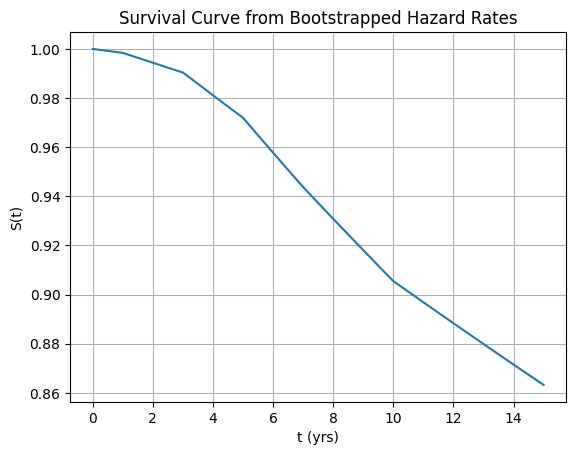

In [4]:
# Plot survival curve
ts = np.linspace(0.0, 15.0, 300)
Ss = [survival_curve(t) for t in ts] 
plt.plot(ts, Ss, label='Survival Probability S(t)')
plt.xlabel('t (yrs)')
plt.ylabel('S(t)')
plt.title('Survival Curve from Bootstrapped Hazard Rates')
plt.grid()

### 2.1 Classical Benchmark using continuous underlying distribution

The CVA is estimated by Monte Carlo simulation using a time-discretized approximation of the continuous-time CVA integral. The underlying asset price is simulated under a lognormal dynamics, and exposures are evaluated on a finite time grid $\{t_i\}_{i=1}^M$.

At each time $t_i$, the simulated underlying price along path $k$ is
$$
S^{(k)}(t_i)
=
S_0 \exp\!\left((\mu - \tfrac{1}{2}\sigma^2)t_i + \sigma \sqrt{t_i}\,Z_i^{(k)}\right),
\qquad k=1,\dots,N.
$$

The corresponding positive exposure is
$$
[V^{(k)}(t_i)]^+
=
\max\!\left(S^{(k)}(t_i) - K\,P(t_i,T),\,0\right).
$$

Let
$$
q(t_{i-1},t_i) = S(t_{i-1}) - S(t_i)
$$
denote the default probability over the interval $(t_{i-1},t_i]$, obtained from the CDS bootstrap. For a fixed path $k$, the pathwise CVA contribution is
$$
\mathrm{CVA}^{(k)}
=
(1-R_{\mathrm{CVA}})
\sum_{i=1}^M
[V^{(k)}(t_i)]^+\,P(0,t_i)\,q(t_{i-1},t_i).
$$

The **Monte Carlo estimator of the CVA** is given by the sample mean over the $N$ simulated paths:
$$
\mathrm{CVA}_{MC}
=
\frac{1}{N}
\sum_{k=1}^N
\mathrm{CVA}^{(k)}
=
\frac{1-R_{\mathrm{CVA}}}{N}
\sum_{k=1}^N
\sum_{i=1}^M
[V^{(k)}(t_i)]^+\,P(0,t_i)\,q(t_{i-1},t_i).
$$

The **Monte Carlo error** associated with this estimator is quantified by its standard error. Let
$$
\sigma_{MC}^2
=
\frac{1}{N-1}
\sum_{k=1}^N
\left(\mathrm{CVA}^{(k)} - \mathrm{CVA}_{MC}\right)^2
$$
denote the sample variance of the pathwise CVA contributions. The standard error of the Monte Carlo estimator is then
$$
\mathrm{SE}\!\left(\mathrm{CVA}_{MC}\right)
=
\frac{\sigma_{MC}}{\sqrt{N}},
$$
which decreases at the canonical Monte Carlo rate $O(N^{-1/2})$.

In [5]:
# =============================
# CVA estimation via (continuous) Monte Carlo
# =============================

# Start timer to measure total execution time
t_start = time.perf_counter()

# Number of independent Monte Carlo runs (for error estimation)
n_runs = 100
CVA_runs = []
Std_runs = []

for run in range(n_runs):
    # Different random seed for each run
    rng = np.random.default_rng(1 + run)

    # Simulate standard normal shocks for the underlying process
    Z = rng.standard_normal(size=(N_paths, M))

    cva_path = np.zeros(N_paths)

    # Time discretization loop
    for i in range(1, M + 1):
        ti = t[i]

        # Simulate the underlying price at time t_i
        Si = S0 * np.exp((mu - 0.5 * sigma**2) * ti
                          + sigma * np.sqrt(ti) * Z[:, i - 1])

        # Positive exposure of the fwd
        Vpos = np.maximum(Si - K * np.exp(-r * (T - ti)), 0.0)

        # Incremental default probability over (t_{i-1}, t_i]
        dq = q_interval(t[i - 1], t[i])

        # Pathwise contribution to CVA
        cva_path += Vpos * P0(ti, r) * dq

    # Monte Carlo estimate of CVA for this run
    CVA_i = LGD * cva_path.mean()

    # Monte Carlo standard error for this run
    var_CVA_i = LGD**2 * cva_path.var(ddof=1) / N_paths
    std_CVA_i = np.sqrt(var_CVA_i)

    CVA_runs.append(CVA_i)
    Std_runs.append(std_CVA_i)

# Convert results to arrays
CVA_runs = np.array(CVA_runs)
Std_runs = np.array(Std_runs)

# Final CVA estimate and standard error of the mean
CVA_mean = CVA_runs.mean()
Std_mean = CVA_runs.std(ddof=1) / np.sqrt(n_runs)

# Stop timer
t_end = time.perf_counter()
elapsed = t_end - t_start

# Report results
print(f"Mean CVA ({n_runs} runs)=", CVA_mean)
print("Standard error of the mean =", Std_mean)
print("Total execution time [s] =", elapsed)

Mean CVA (100 runs)= 5.5286311814213093e-05
Standard error of the mean = 2.381095302277188e-08
Total execution time [s] = 0.7935305000282824


### 2.2 Classical Benchmark using discrete underlying distribution

In this section (replicating Sections 3 and 4.1 of Alcázar et al.) we address the classical estimation of the CVA by discretizing both the time dimension and the underlying asset price, with the aim of constructing a discrete joint distribution that will later serve as input for the quantum algorithm.

We consider a uniform time grid $\{t_i\}_{i=1}^M$ on the interval $[0,T]$. By construction, the marginal distribution of time is uniform and satisfies $P(t_i)=1/M$. At each time point $t_i$, the underlying asset price $S(t_i)$ is modeled as a geometric Brownian motion. A large number of independent samples of the marginal distribution of $S(t_i)$ are generated using classical Monte Carlo simulation. Since temporal correlations are not required at this stage, each marginal distribution $S(t_i)$ is simulated directly from the initial value $S_0$, which allows for an efficient estimation of the conditional density $P(s\mid t_i)$ at each time step.

The price space is discretized by introducing $N=2^n$ bins $\{s_j\}_{j=1}^N$. A global price range $[s_0,s_N]$ is defined using the sample mean and sample standard deviation of the asset price at maturity $T$. In particular, we set
$$
s_0 = \max\{\hat\mu_T - k\hat\sigma_T,\,0\}, \qquad
s_N = \hat\mu_T + k\hat\sigma_T,
$$
for a fixed constant $k=3$, and discretize this interval uniformly. For each time $t_i$, the conditional discrete distribution $P(s_j\mid t_i)$ is approximated by a normalized histogram over this price grid.

Under these assumptions, the joint discrete distribution of time and price is approximated as
$$
\mathcal{P}(s_j,t_i) = P(t_i)\,P(s_j\mid t_i) = \frac{1}{M} P(s_j\mid t_i),
$$
which ensures that the marginal distribution over time satisfies $P(t_i)=1/M$ exactly. This construction leads to the following approximation of the expected exposure at time $t_i$:
$$
\tilde{E}(t_i)
= \sum_{j=1}^N \frac{\mathcal{P}(s_j,t_i)}{P(t_i)}\, v(s_j,t_i)
= M \sum_{j=1}^N \mathcal{P}(s_j,t_i)\, v(s_j,t_i),
$$
where $v(s_j,t_i)$ denotes the positive payoff of the derivative evaluated at a representative price of the $j$-th bin.

Combining the discretizations in time and price, the resulting discrete approximation of the CVA is given by
$$
\mathrm{CVA}
= M(1-R)\sum_{i=1}^M \sum_{j=1}^N
\mathcal{P}(s_j,t_i)\, v(s_j,t_i)\, p(t_i)\, q(t_i),
$$
where $p(t_i)$ denotes the discount factor and $q(t_i)$ the incremental default probability over the interval $(t_{i-1},t_i]$.

In this section of the work, we implement this construction entirely on a classical computer: we simulate the marginal price distributions, discretize them on the chosen price grid, and evaluate the resulting discrete CVA. This classical implementation provides both a benchmark for comparison and a controlled setting to study the convergence of the CVA estimate as the number of price discretization levels $n$ increases.

In [ ]:
# =============================
# Discrete CVA estimation CVA(n)
# =============================

t_start = time.perf_counter()

n_runs = 100
num_s = np.arange(1, 15)   # n = 1,...,14

CVA_runs = {n: [] for n in num_s}

for run in range(n_runs):
    rng = np.random.default_rng(1 + run)

    # Marginal samples S(t_i)
    S_by_time = simulate_S(S0=S0, mu=mu, sigma=sigma, t=t, Z=Z)

    # Compute CVA for all n in one call
    CVA_vals = discrete_cva(
        S_by_time=S_by_time,
        t=t,
        K=K,
        r=r,
        T=T,
        LGD=LGD,
        P0_func=P0_flat,
        q_interval=q_interval,
        n=num_s,
        n_sigma=3.0,
    )

    # Store results
    for n, cva_n in zip(num_s, CVA_vals):
        CVA_runs[n].append(cva_n)

# Convert to arrays
CVA_runs = {n: np.array(CVA_runs[n], dtype=float) for n in num_s}

t_end = time.perf_counter()
elapsed = t_end - t_start

print("CVA(n) computation finished.")
print("Elapsed time [s] =", elapsed)

CVA(n) computation finished.
Elapsed time [s] = 8.415396299911663


In [ ]:
# =============================
# Proxy for CVA(\infty) 
# =============================

t_start = time.perf_counter()

n_runs = 100
n_inf = 20

CVA_inf_runs = np.zeros(n_runs)

for run in range(n_runs):
    rng = np.random.default_rng(1 + run)

    # Marginal samples S(t_i)
    S_by_time = simulate_S(S0=S0, mu=mu, sigma=sigma, t=t, Z=Z)

    # Single call with scalar n
    CVA_inf_runs[run] = discrete_cva(
        S_by_time=S_by_time,
        t=t,
        K=K,
        r=r,
        T=T,
        LGD=LGD,
        P0_func=P0_flat,
        q_interval=q_interval,
        n=n_inf,
        n_sigma=3.0,
    )

CVA_inf_mean = CVA_inf_runs.mean()
CVA_inf_std_err = CVA_inf_runs.std(ddof=1) / np.sqrt(n_runs)

t_end = time.perf_counter()
elapsed = t_end - t_start

print("CVA(inf) computation finished.")
print("Elapsed time [s] =", elapsed)


CVA(inf) computation finished.
Elapsed time [s] = 1.3993672999786213


In [11]:
# ==============================================================
# Discrete CVA results by discretization level n
# ==============================================================

print("\nDISCRETE CVA ESTIMATES (per price discretization level)")
print("Each line reports the Monte Carlo mean CVA and the standard error of the mean.")
print("--------------------------------------------------------------")

for n in num_s:
    CVA_mean = CVA_runs[n].mean()
    Std_mean = CVA_runs[n].std(ddof=1) / np.sqrt(n_runs)

    print(
        f"n = {n:2d}   N = {2**n:5d} bins    "
        f"Mean CVA = {CVA_mean:.10e}    "
        f"Std. error (mean) = {Std_mean:.2e}"
    )

print("--------------------------------------------------------------")

# ==============================================================
# Reference value: CVA(infinity)
# ==============================================================

CVA_inf_mean = CVA_inf_runs.mean()
CVA_inf_std_err = CVA_inf_runs.std(ddof=1) / np.sqrt(n_runs)

print("REFERENCE CVA (proxy for n → ∞)")
print("Computed as CVA(n_inf) with a very fine price grid.")
print("--------------------------------------------------------------")
print(
    f"n_inf = {n_inf:2d}  |  "
    f"Mean CVA(inf) = {CVA_inf_mean:.10e}  |  "
    f"Std. error (mean) = {CVA_inf_std_err:.2e}"
)

# ==============================================================
# Timing information
# ==============================================================

print("\nTotal execution time [s] =", elapsed)



DISCRETE CVA ESTIMATES (per price discretization level)
Each line reports the Monte Carlo mean CVA and the standard error of the mean.
--------------------------------------------------------------
n =  1   N =     2 bins    Mean CVA = 1.9899130208e-04    Std. error (mean) = 8.98e-08
n =  2   N =     4 bins    Mean CVA = 7.3495338353e-05    Std. error (mean) = 6.47e-08
n =  3   N =     8 bins    Mean CVA = 5.3802318297e-05    Std. error (mean) = 1.92e-08
n =  4   N =    16 bins    Mean CVA = 5.3510766164e-05    Std. error (mean) = 3.15e-08
n =  5   N =    32 bins    Mean CVA = 5.2869208667e-05    Std. error (mean) = 2.31e-08
n =  6   N =    64 bins    Mean CVA = 5.2787837542e-05    Std. error (mean) = 2.65e-08
n =  7   N =   128 bins    Mean CVA = 5.2758202668e-05    Std. error (mean) = 2.47e-08
n =  8   N =   256 bins    Mean CVA = 5.2754389547e-05    Std. error (mean) = 2.53e-08
n =  9   N =   512 bins    Mean CVA = 5.2752270226e-05    Std. error (mean) = 2.52e-08
n = 10   N =  1024

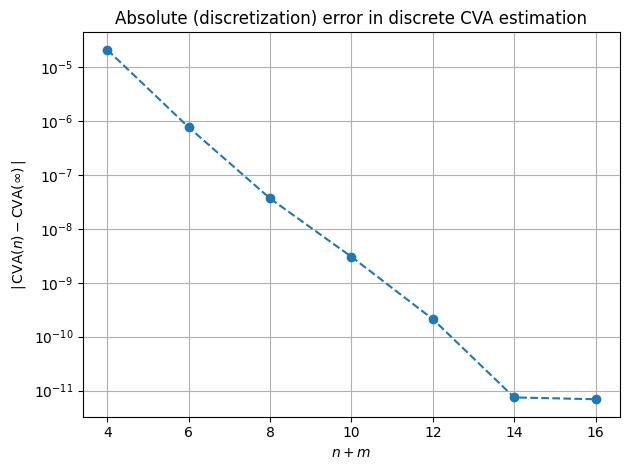

In [10]:
m = int(np.log2(M)) 
ns_even = np.arange(2, 16, 2)   # n = 2,4,...,14

# CVA(n) medio (a partir del diccionario, no del dataframe)
CVA_disc_mean = np.array(
    [CVA_runs[n].mean() for n in ns_even],
    dtype=float
)

# CVA(inf) como referencia
cva_inf = float(CVA_inf_mean)

# Error absoluto respecto a CVA(inf)
abs_err = np.abs(CVA_disc_mean - cva_inf)

# Eje x: n + m
x_vals = ns_even + m            # 4,6,...,16

plt.figure()
plt.plot(x_vals, abs_err, marker="o", linestyle="--")
plt.yscale("log")

ax = plt.gca()
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,)))
ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))

plt.xlabel(r"$n+m$")
plt.ylabel(r"$|\,\mathrm{CVA}(n)-\mathrm{CVA}(\infty)\,|$")
plt.title("Absolute (discretization) error in discrete CVA estimation")
plt.grid(True, which="major")
plt.tight_layout()
plt.show()

*To be implemented*: Discretized CVA estimation  including scaling factors $C_v, C_p, C_q$:
$$
\widetilde{CVA}  = M(1-R)\, C_v\,C_q\,C_p\,\sum_{i=1}^N\sum_{j=1}^M \mathcal{P}(s_j,t_i)\tilde{v}(s_j,t_i)\tilde{p}(t_i)\tilde{q}(t_i)
$$

*Implemented*: Use function `discrete_cva_paper_form`:

In [ ]:
cva_2 = discrete_cva_paper_form(
    S_by_time=S_by_time,
    t=t,
    K=K,
    r=r,
    T=T,
    LGD=LGD,
    P0_func=P0_flat,
    q_interval=q_interval,
    n=2,                 # CVA(2)
    n_sigma=3.0,
    C_v=1.8201814,
    C_p=1.0,
    C_q=0.0002038,
)